In [1]:
%reload_ext autoreload
%autoreload 2

# Imports

In [2]:
from kret_notebook import *  # NOTE import first
from kret_lgbm._core.lgbm_nb_imports import *
from kret_lightning._core.lightning_nb_imports import *
from kret_matplotlib._core.mpl_nb_imports import *
from kret_np_pd._core.np_pd_nb_imports import *
from kret_optuna._core.optuna_nb_imports import *
from kret_polars._core.polars_nb_imports import *
from kret_rosetta._core.rosetta_nb_imports import *
from kret_sklearn._core.sklearn_nb_imports import *
from kret_torch_utils._core.torch_nb_imports import *
from kret_tqdm._core.tqdm_nb_imports import *
from kret_type_hints._core.types_nb_imports import *
from kret_utils._core.utils_nb_imports import *

# from kret_wandb._core.wandb_nb_imports import *  # NOTE this is slow to import

Loaded environment variables from /Users/Akseldkw/coding/Columbia/NBA-Timeout-Impact/.env
[kret_lgbm._core.lgbm_nb_imports] Imported kret_lgbm._core.lgbm_nb_imports in 1.9798 seconds
[kret_lightning._core.lightning_nb_imports] Imported kret_lightning._core.lightning_nb_imports in 4.1605 seconds
[kret_matplotlib._core.mpl_nb_imports] Imported kret_matplotlib._core.mpl_nb_imports in 0.3760 seconds
[kret_np_pd._core.np_pd_nb_imports] Imported kret_np_pd._core.np_pd_nb_imports in 0.0005 seconds
[kret_optuna._core.optuna_nb_imports] Imported kret_optuna._core.optuna_nb_imports in 0.0009 seconds
[kret_polars._core.polars_nb_imports] Imported kret_polars._core.polars_nb_imports in 0.0000 seconds
[kret_rosetta._core.rosetta_nb_imports] Imported kret_rosetta._core.rosetta_nb_imports in 0.0000 seconds
[kret_sklearn._core.sklearn_nb_imports] Imported kret_sklearn._core.sklearn_nb_imports in 0.0858 seconds
[kret_torch_utils._core.torch_nb_imports] Imported kret_torch_utils._core.torch_nb_imports i

In [3]:
from nba_timeout_impact.nb_imports import *

# TV / mandatory timeout study

Two questions:

1. **Visual evidence** that mandatory timeouts in cdnnba (post-2017) already exist as ordinary `subType="full"` rows, clustering at the rulebook trigger marks.
2. **Reclassification** of each timeout row's role (slot_K_mandatory / slot_K_absorbed / discretionary / challenge), tested on the v3 labeled era (1998-2016) against ground-truth `Official` / `Official TV` subTypes.

# Load data

In [4]:
from nba_timeout_impact.datasets.memo_nbastatsv3 import NBAMemoDF
from nba_timeout_impact.datasets.memo_cdnnba_pl import CDNNBAMemoPL
from nba_timeout_impact.analyses.tv_timeout_validation import TVTimeoutValidation

memo_v3 = NBAMemoDF.load_all()  # nbastatsv3 + nbastats v2 (~1s)
memo_cdn = CDNNBAMemoPL.load_all()  # cdnnba post-2017 (~3s)

Validating cdnnba data (Polars)...
  Passed (4,168,786 rows, 74 cols, 1 warnings).
Validating boxscores data (Polars)...
  Passed (217,190 rows, 36 cols).
Validating player_advanced_stats data (Polars)...
  Passed (3,400 rows, 119 cols).
Validating player_season_stats data (Polars)...
  Passed (5,174 rows, 31 cols).
Validating rotations data (Polars)...
  Passed (1,905,583 rows, 16 cols, 1 warnings).
Validating stints data (Polars)...
  Passed (2,145,106 rows, 14 cols, 1 warnings).


# Part 1 — Density of cdnnba timeouts by clock bin

The cdnnba memo has a parameterized `sr_bin(width)` column. Plot the
density of `full` and `challenge` timeouts at 15s / 30s / 60s resolutions
to see where they cluster relative to the rulebook trigger marks (7:00
and 3:00 = sr=420 and sr=180).

Calculating sr_bin(15,)
Calculating sr_bin(30,)
Calculating sr_bin(60,)


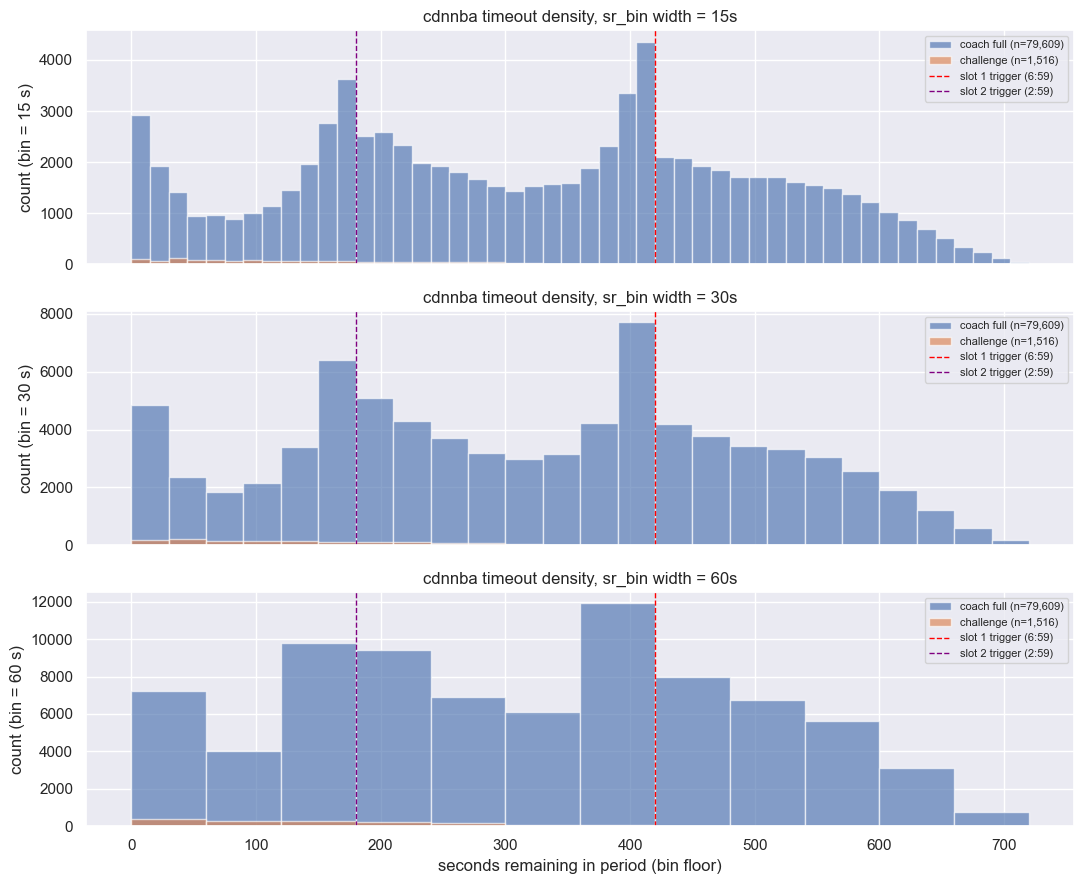

In [5]:
import matplotlib.pyplot as plt
import polars as pl
import numpy as np

df = pl.DataFrame._from_pydf(memo_cdn.cdnnba._df)
df = df.filter((pl.col("actionType") == "timeout") & pl.col("period").is_in([1, 2, 3, 4]))

fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
for ax, width in zip(axes, [15, 30, 60]):
    binned = df.with_columns(memo_cdn.sr_bin(width).gather(df["orderNumber"] - df["orderNumber"]))  # dummy alignment
    # simpler: just compute bins directly here
    bins = (df["seconds_remaining"] // width * width).cast(pl.Int32)
    df2 = df.with_columns(bins.alias("sr_bin"))
    for sub, color, label in [("full", "C0", "coach full"), ("challenge", "C1", "challenge")]:
        vals = df2.filter(pl.col("subType") == sub)["sr_bin"].to_numpy()
        if len(vals) == 0:
            continue
        ax.hist(
            vals, bins=np.arange(0, 720 + width, width), alpha=0.65, label=f"{label} (n={len(vals):,})", color=color
        )
    ax.axvline(420, color="red", linestyle="--", linewidth=1, label="slot 1 trigger (6:59)")
    ax.axvline(180, color="purple", linestyle="--", linewidth=1, label="slot 2 trigger (2:59)")
    ax.set_ylabel(f"count (bin = {width} s)")
    ax.set_title(f"cdnnba timeout density, sr_bin width = {width}s")
    ax.legend(loc="upper right", fontsize=8)
axes[-1].set_xlabel("seconds remaining in period (bin floor)")
plt.tight_layout()
plt.show()

The bimodal peaks just inside the 7:00 and 3:00 marks confirm mandatories
are already present in cdnnba as ordinary `full` timeouts — no injection
needed. The classifier's job is to label *which* of these are
mandatory-driven vs discretionary.

# Part 2 — Reclassification on v3 labeled era

Apply `TVTimeoutValidation.classify_timeouts` to v3 PBP **restricted to 2013-2016** (last 4 years of the labeled era) and
compare predictions (`slot_K_mandatory`) against v3's explicit `Official`
/ `Official TV` ground-truth labels. The classifier sees only `(gameId,
period, seconds_remaining, actionType, order)` — never `subType` (no
cheating).

Filtering to 2013-2016 gives us a cleaner pre-2017 sample (consistent
broadcast/rule conventions, modern data quality) without leaking any
post-2017 rule changes.


## Headline metrics — both pre-2017 modes (seasons 2013-2016)


In [ ]:
import pandas as pd

SEASONS = (2013, 2016)
rows = []
for mode in ["cascading", "independent"]:
    r = TVTimeoutValidation.validate_against_v3(memo_v3, seasons=SEASONS, pre_2017_mode=mode)
    pp = TVTimeoutValidation.per_period_existence_score(memo_v3, seasons=SEASONS, pre_2017_mode=mode)
    rows.append(
        {
            "pre_2017_mode": mode,
            "per-event TP": r.tp,
            "FP": r.fp,
            "FN": r.fn,
            "per-event P": round(r.precision, 3),
            "per-event R": round(r.recall, 3),
            "per-event F1": round(r.f1, 3),
            "per-period F1": pp["f1"],
        }
    )
pd.DataFrame(rows)

,pre_2017_mode,per-event TP,FP,FN,per-event P,per-event R,per-event F1,per-period F1
0,cascading,6100,3179,2191,0.657,0.736,0.694,0.8881
1,independent,6275,4072,2016,0.606,0.757,0.673,0.8881


## Per-period breakdown (best mode)

In [ ]:
r = TVTimeoutValidation.validate_against_v3(memo_v3, seasons=SEASONS, pre_2017_mode="cascading")
print(f"per-event greedy match, 60s tolerance (seasons {SEASONS}):")
print(r.per_period.to_string(index=False))

per-event greedy match, 60s tolerance (seasons (2013, 2016)):
 period   TP   FP   FN  precision   recall      f1
      1    0    0    1   0.000000 0.000000 0.00000
      2 3142 1596 1250   0.663149 0.715392 0.68828
      3    0    0    3   0.000000 0.000000 0.00000
      4 2958 1583  937   0.651398 0.759435 0.70128


## Confusion matrix: where the classifier disagrees with v3

Rows are v3 ground-truth `subType`; columns are predicted `timeout_role`.
Strong diagonal would mean perfect classification. Off-diagonal cells
tell us where the rulebook walk diverges from v3 labels.

In [ ]:
confusion = TVTimeoutValidation.confusion_matrix_v3(memo_v3, seasons=SEASONS, pre_2017_mode="cascading")

In [9]:
confusion

predicted_role,discretionary,slot_1_absorbed,slot_1_mandatory,slot_2_absorbed,slot_2_mandatory,slot_3_absorbed,slot_3_mandatory,TOTAL
gt_subType,,,,,,,,
,10,0,4,0,1,0,0,15
Official,2090,0,4414,108,975,201,503,8291
Regular,40814,3334,2411,1438,549,626,158,49330
Short,11290,178,11,311,130,232,123,12275
TOTAL,54204,3512,6840,1857,1655,1059,784,69911


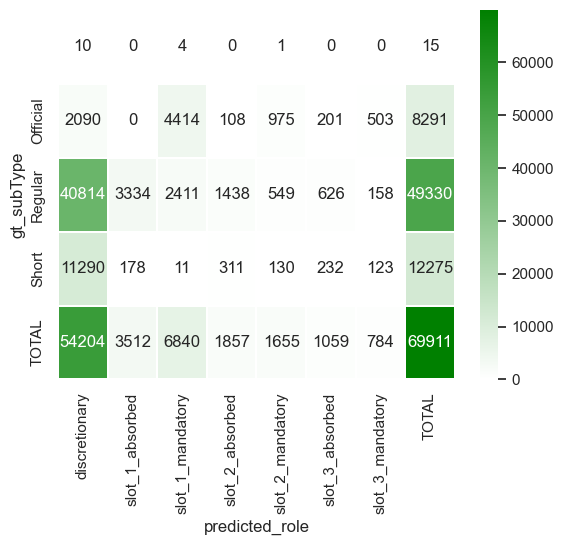

In [10]:
UKS_MPL.heatmap_df(confusion)

## Where the classifier works and doesn't

**Working well**:
- Most `Regular` (coach voluntary) TOs are correctly tagged as `discretionary` or appropriate `_absorbed` slots.
- ~70 % of `Official` GT rows are correctly predicted as some `slot_K_mandatory`.
- `Coach Challenge` rows are cleanly identified.

**Failure modes**:
- `Official` rows labeled as `discretionary`: a second/third Official in the same (game, period) when our cascading model says only one mandatory fires. This is the strongest evidence that pre-2017 may have allowed *independent* firing — though switching modes only nudges F1 slightly.
- `Official` rows labeled as `slot_K_absorbed`: an earlier coach TO ate the absorption window, so the classifier reasonably tags the next TO as absorbing the next slot — but v3 still labels it `Official`. This suggests v3's `Official` may capture *every* TV-break event independent of absorption logic.
- `Regular` rows labeled as `slot_K_mandatory`: false positives when a coach TO happens at or just below a mandatory threshold. The classifier can't tell from position alone whether this was voluntary or auto-charged.
- `Short` rows mostly land in `discretionary` or `_absorbed`. `Short` (20-second timeouts) were a separate event class pre-2017 — they probably shouldn't be candidates for mandatory roles at all. **Possible fix**: drop `Short` from the candidate set before running the rulebook walk.

## Sanity: cdnnba (post-2017) reclassification (no GT, just role distribution)

In [11]:
classified = TVTimeoutValidation.classify_timeouts(memo_cdn.cdnnba, source="cdnnba")
tos = classified.filter(pl.col("actionType") == "timeout")
print(f"total cdnnba timeouts: {tos.height:,}")
print(f'per game: {tos.height / memo_cdn.cdnnba["gameId"].n_unique():.2f}')
print()
print(
    tos.group_by("timeout_role").agg(pl.len().alias("n")).sort("n", descending=True).to_pandas().to_string(index=False)
)

total cdnnba timeouts: 82,197
per game: 11.02

    timeout_role     n
   discretionary 31258
 slot_1_absorbed 20406
 slot_2_absorbed 15190
slot_1_mandatory  9421
slot_2_mandatory  4406
       challenge  1516


# Sandbox

In [12]:
memo_v3.data.season.value_counts()

season
2015    641644
2014    633526
2013    632199
2004    630209
2005    625271
2006    623183
2007    620807
2010    619179
2009    618751
2008    616018
1999    615138
2012    612525
2002    606770
2000    602342
2003    601034
2016    597984
2001    595588
2011    504934
1998    379082
Name: count, dtype: int64